<!-- ![FinTech Innovations Logo](images/FinTech.png) -->
<img src="images/FinTech.png" alt="FinTech Innovations Logo" width="400">

# FinTech Loan Approval Process - A Machine Learning Approach

## Overview
A machine learning approach can significantly improve the consistency and efficiency of FinTech Innovations' loan approval process.  After comparing Logistic Regression and Random Forest models, Logistic Regression achieved the best cross-validation recall and was selected as the final model.  When assessing the test dataset, the model achieved a recall of 0.926, an F1-score of 0.830, and an ROC-AUC of 0.977, demonstrating strong predictive performance and maintaining the interpretability needed for financial decisions.  Analysis showed that financial stability and credit history were the strongest drivers of loan approval decisions.  Features such as Total Debt-to-Income Ratio, Bankruptcy History, Previous Loan Defaults, Monthly Income, Loan Amount, and Employment Status had the greatest influence on the model's predictions.  These findings align with established lending practices and suggest that the model is learning meaningful patterns from the historical data.  While the model should not completely replace the loan officers' judgment, it can serve as an effective support tool by automatically identifying low-risk applicants, flagging higher-risk applications for additional review, and helping loan officers make faster and more consistent decisions.

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

FinTech Innovations currently relies heavily on loan officers manually reviewing applications to decide whether an applicant should be approved. Although manual review allows individual circumstances to be considered, it can also produce inconsistent decisions based on how loan officers may interpret data points from the same application differently. It is also time-consuming, which increases applicant wait times and limits the number of applications the company can process. 

The main stakeholders in this project include the loan applicants, loan officers, bank management, and the Risk Analytics team.  Loan applicants need decisions that are timely, consistent, and fair. Loan officers need an interpretable risk assessment that supports their decision-making process. Bank management needs the model to improve profitability while controlling the number of loans that default. The Risk Analytics team needs a model that performs reliably on data related to new, unseen applications. 

The two most important model errors have substantially different financial consequences:
- A false approval occurs when the model recommends approving an applicant who later defaults on the loan repayments. Each false approval is expected to cost approximately $50,000.
- A false denial occurs when the model recommends denying a creditworthy applicant who would have repaid the loan. Each false denial represents approximately $8,000 in lost profit.

Because a false approval is about ~6.25 times more costly than a false denial, the model should place greater emphasis on identifying applicants who are likely to default. However, we do not want to deny too large a percentage of applicants as this would reduce overall lending revenue, potentially harm applicants, and fail to meet the objective of identifying overlooked creditworthy borrowers.  Therefore, I would use a classification approach that predicts whether an applicant is likely to default on the loan. The output could be described as a risk score, providing the likelihood of default with a probabilistic classificaion model. For example, the model may estimate that an applicant has a 10% probability of default. Loan officers can use this probability as a risk score, comparing it to a predetermined approval threshold that is based on the company's financial costs and risk tolerance.  This probability-based classification model would provide more flexibility than a simple approve-or-deny prediction. Low-risk applications could be automatically approved, high-risk applications could be declined or escalated, and borderline applications could remain subject to manual review where other factors could be weighed to support a final decision. 

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice

**Evaluation Metrics**
- **Recall for the Default Class**:  recall measures the percentage of actual defaulters that the model correctly identifies.  Recall is important because a false negative means that the model predicts an applicant will repay, but the applicant actually defaults. Each of these errors may cost the company approximately $50,000. Therefore, the model should have strong recall for the default class so that it identifies as many risky applicants as possible.  However, recall should not be considered alone. A model could achieve very high recall by predicting that almost every applicant will default, but this would cause many creditworthy applicants to be denied.

- **Precision for the Default Class**:  precision measures the percentage of applicants predicted to default who actually default.  Precision is important because a false positive occurs when the model identifies a creditworthy applicant as likely to default. Denying that applicant may cause the company to lose approximately $8,000 in expected profit.  Using precision together with recall helps ensure that the model identifies risky applicants without unnecessarily denying too many good applicants.

- **F1-Score**:  F1-score combines precision and recall into one measurement.  The F1-score is useful because it provides a balanced measure of performance when the classes are imbalanced. It will help compare models that may have different trade-offs between identifying defaults and avoiding unnecessary denials.
Recall should still receive greater attention than precision because approving a bad loan is much more expensive than denying a good loan.


**Baseline Performance**
Before evaluating advanced models, performance should be compared with simple baseline methods.  The first baseline should be a classifier that always predicts the majority class. A second baseline could predict classes according to the existing default rate in the dataset. When reliable historical information is available, the current manual loan approval process should also be used as a business baseline.

Each baseline should be evaluated using:
- Default recall
- Default precision
- F1-score
- Precision-Recall AUC
These baselines will show whether the machine learning model provides meaningful improvement over simple predictions or the current manual process.

The following initial targets can be used to evaluate whether the model is successful:
- Achieve at least 80% recall for the default class.  Recall is prioritized because missed defaults are the most expensive type of error. 
- Maintain at least 60% precision for the default class.  The precision target helps prevent the model from becoming overly strict and rejecting too many profitable applicants.
- Achieve an F1-score that is clearly higher than the dummy-classifier baseline
- Produce a Precision-Recall AUC higher than the default rate and baseline models
- Keep training and validation results reasonably close to reduce the risk of overfitting

## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


### EDA overview:
- 20,000 records, with 0 duplicate rows
- 36 total columns, none of which have any NULL values
- `LoanApproved` rate is %76.1% declined, 23.9% approved

### Feature Types:
- **categorical_features**
   - EmploymentStatus
   - MaritalStatus
   - HomeOwnershipStatus
   - LoanPurpose
- **ordinal_features** - could be considered categorical, but might be good to order them from lowest to highest education level
   - EducationLevel
- **binary_features**
   - BankruptcyHistory
   - PreviousLoanDefaults
   - LoanApproved
- **date_features**
   - ApplicationDate - ranges from 01JAN2018 - 03OCT2072; as of 24JUL2026, 84.4% of records have an Application date in the futrue
- all other fields are **numerical**

### Correlation and multicollinearity

The fields most closely correlated with LoanApproved include
- RiskScore: -0.766
    - likely assigned after the loan evaluation, not an actual indicator of who is likely to default
- MonthlyOncome:  0.606
- AnnualIncome:  0.597
- TotalDebtToIncomeRatio:  -0.410
- InterestRate:  -0.302
    - likely assigned after the loan evaluation, not an actual indicator of who is likely to default

Highly correlated feature pairs with correlation of 0.75 or higher:
- MonthlyIncome & AnnualIncome:  0.990
- Experience & Age:  0.983
- NetWorth	& TotalAssets:  0.979
- InterestRate & BaseInterestRate:  0.835
- MonthlyLoanPayment & LoanAmount:  0.781
- RiskScore & LoanApproved:  -0.766

### Patterns
- No `Age` below 18 (expected minimum age requried for approval) or above 100 (technically possible, but unlikely)
- No `CreditScore` below 300 (minimum possible) or above 850 (maximum possible)
- `LoanApproced`, `BanruptcyHistory`, and `PreviousLoanDefaults` within the appropriate ranges
- No negative numerical values

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, classification_report, confusion_matrix, f1_score, recall_score, roc_auc_score, ConfusionMatrixDisplay

# Load data
loan_df = pd.read_csv('Loan.csv')

In [2]:
# EDA Code Here - Create New Cells As Needed

# Display the first five rows
display(loan_df.head())

# Display dataset shape
display(loan_df.shape)

# Display dataset info
display(loan_df.info())

# Display column names
print('\nColumn Names:\n', loan_df.columns)

# Count duplicate rows
duplicate_count = loan_df.duplicated().sum()
print('\nDuplicate rows:', duplicate_count)

# Check missing values per column
missing_values = loan_df.isnull().sum()
print('\nMissing values in each column:')
print(missing_values)

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


(20000, 36)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

None


Column Names:
 Index(['ApplicationDate', 'Age', 'AnnualIncome', 'CreditScore',
       'EmploymentStatus', 'EducationLevel', 'Experience', 'LoanAmount',
       'LoanDuration', 'MaritalStatus', 'NumberOfDependents',
       'HomeOwnershipStatus', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory',
       'LengthOfCreditHistory', 'SavingsAccountBalance',
       'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
       'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth',
       'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment',
       'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore'],
      dtype='object')

Duplicate rows: 0

Missing values in each column:
ApplicationDate               0
Age                           0
AnnualIncome                  0
CreditScore                 

In [3]:
# Basic data characterisitics

# Display descriptive statistics for numerical features
display(loan_df.describe().T)

# Display descriptive statistics for categorical features
display(loan_df.describe(include="object").T)

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
AnnualIncome,20000.0,59161.473550,40350.845168,15000.000000,31679.000000,48566.000000,74391.000000,4.853410e+05
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01


,count,unique,top,freq
ApplicationDate,20000,20000,2018-01-01,1
EmploymentStatus,20000,3,Employed,17036
EducationLevel,20000,5,Bachelor,6054
MaritalStatus,20000,4,Married,10041
HomeOwnershipStatus,20000,4,Mortgage,7939
LoanPurpose,20000,5,Home,5925


In [4]:
# Categorize features by type

# Categorical nominal features
categorical_features = [
    'EmploymentStatus',
    'MaritalStatus',
    'HomeOwnershipStatus',
    'LoanPurpose'
]

# Ordinal categorical features
ordinal_features = [
    'EducationLevel'
]

# Binary features
binary_features = [
    'BankruptcyHistory',
    'PreviousLoanDefaults',
    'LoanApproved'
]

# Numerical features
numerical_features = [
    col for col in loan_df.select_dtypes(include=np.number).columns
    if col not in binary_features
]

# Date feature
date_features = [
    'ApplicationDate'
]

print('Numerical features:')
print(numerical_features)

print('\nCategorical features:')
print(categorical_features)

print('\nOrdinal features:')
print(ordinal_features)

print('\nBinary features:')
print(binary_features)

print('\nDate features:')
print(date_features)

Numerical features:
['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore']

Categorical features:
['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']

Ordinal features:
['EducationLevel']

Binary features:
['BankruptcyHistory', 'PreviousLoanDefaults', 'LoanApproved']

Date features:
['ApplicationDate']




EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64


MaritalStatus
Married     10041
Single       6078
Divorced     2882
Widowed       999
Name: count, dtype: int64


HomeOwnershipStatus
Mortgage    7939
Rent        6087
Own         3938
Other       2036
Name: count, dtype: int64


LoanPurpose
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other                 2006
Name: count, dtype: int64


EducationLevel
Bachelor       6054
High School    5908
Associate      4034
Master         3050
Doctorate       954
Name: count, dtype: int64


BankruptcyHistory
0    18952
1     1048
Name: count, dtype: int64


PreviousLoanDefaults
0    17999
1     2001
Name: count, dtype: int64


LoanApproved
0    15220
1     4780
Name: count, dtype: int64


,Count,Percent
Denied,15220,76.1
Approved,4780,23.9


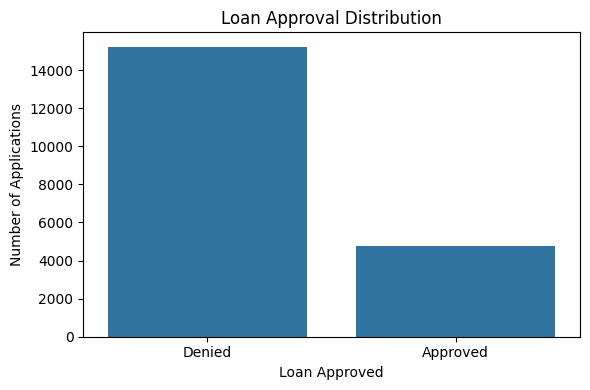

In [5]:
# Examine feature values and target distribution

# Inspect categorical, ordinal, and binary values
features_to_inspect = (
    categorical_features +
    ordinal_features +
    binary_features
)

for column in features_to_inspect:
    print(f'\n')
    print(loan_df[column].value_counts(dropna=False))

# Target distribution
target_summary = pd.DataFrame({
    'Count': loan_df['LoanApproved'].value_counts().sort_index(),
    'Percent': (
        loan_df['LoanApproved']
        .value_counts(normalize=True)
        .sort_index() * 100
    )
})

target_summary.index = ['Denied', 'Approved']
display(target_summary)

plt.figure(figsize=(6, 4))
sns.countplot(data=loan_df, x='LoanApproved')
plt.title('Loan Approval Distribution')
plt.xlabel('Loan Approved')
plt.ylabel('Number of Applications')
plt.xticks([0, 1], ['Denied', 'Approved'])
plt.tight_layout()
plt.show()

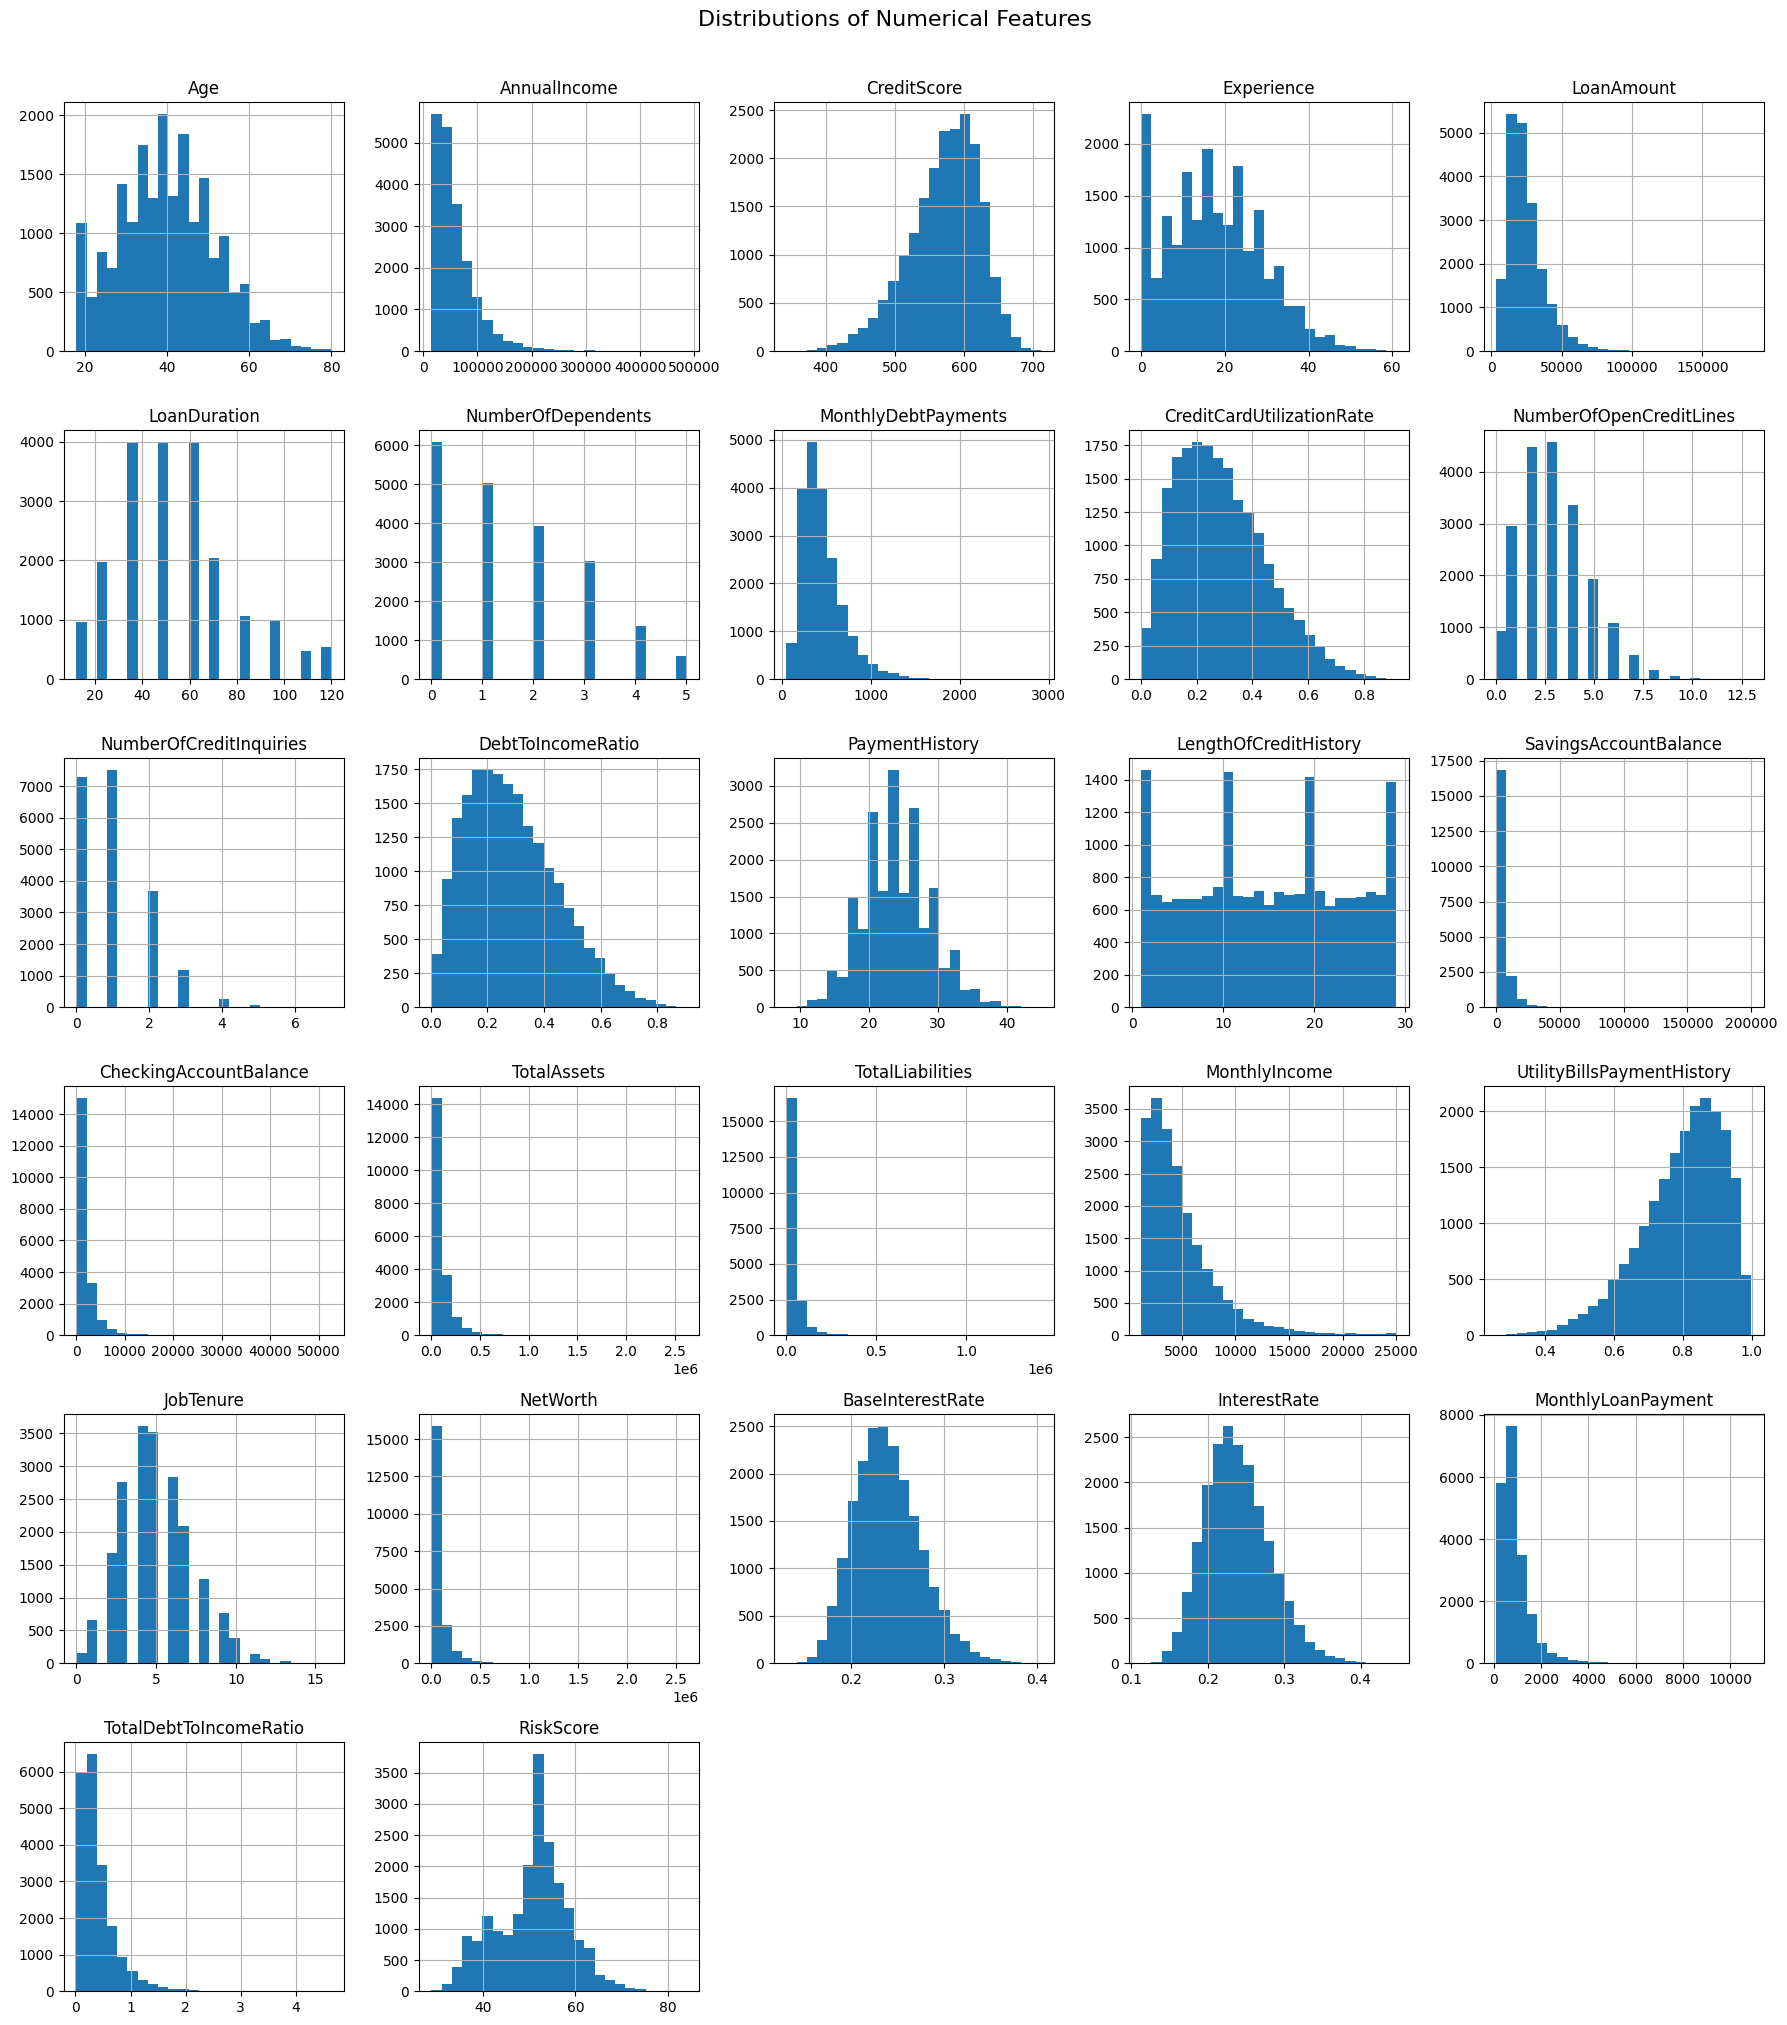

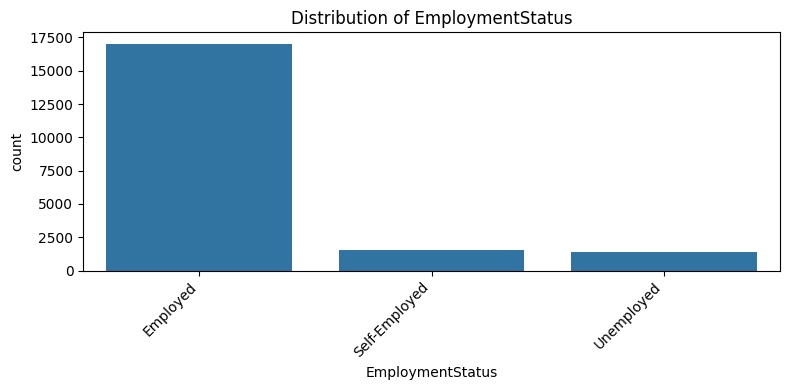

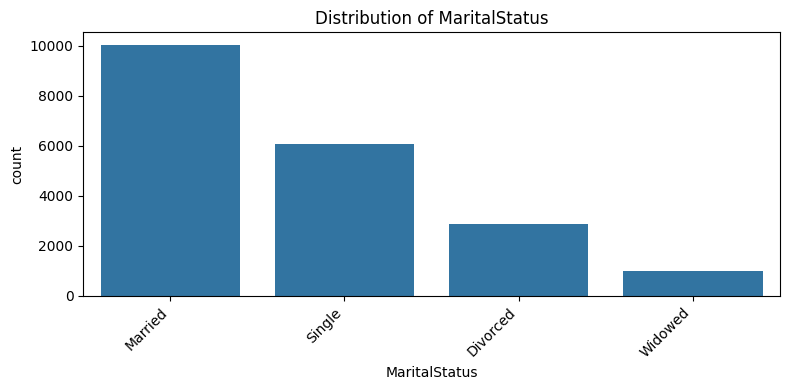

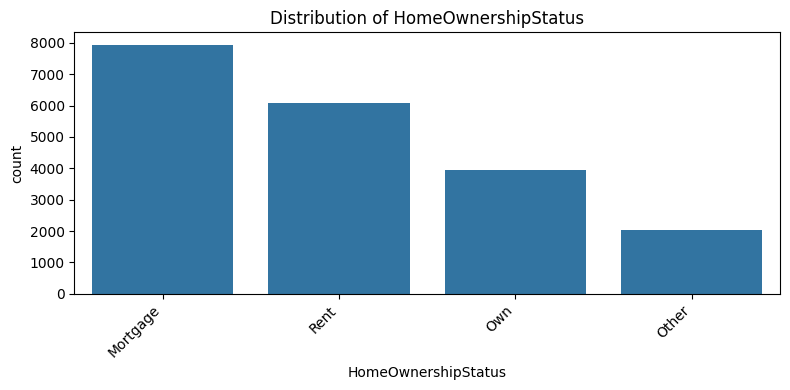

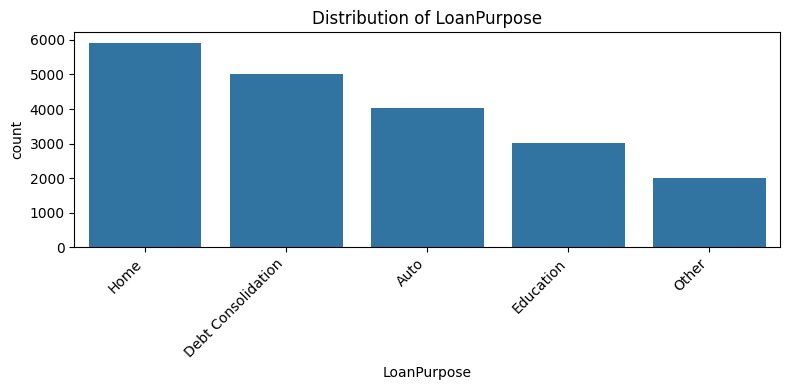

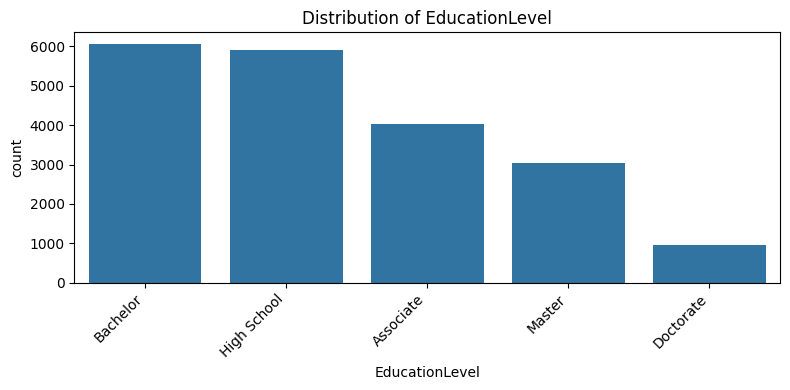

In [6]:
# Examine feature values and target distribution

# Numerical distributions
loan_df[numerical_features].hist(
    bins=25,
    figsize=(18, 20)
)

plt.suptitle(
    'Distributions of Numerical Features',
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()

# Categorical and ordinal distributions
for column in categorical_features + ordinal_features:
    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=loan_df,
        x=column,
        order=loan_df[column].value_counts().index
    )

    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

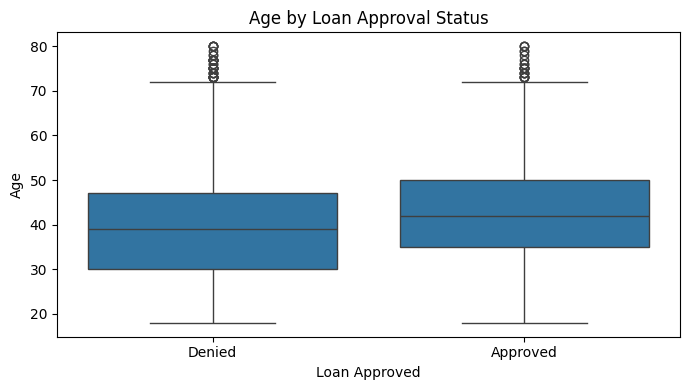

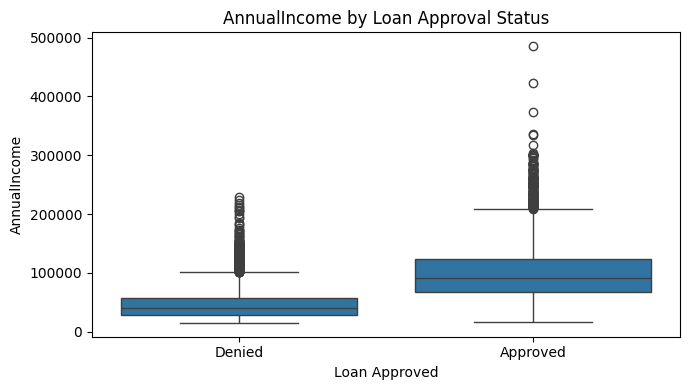

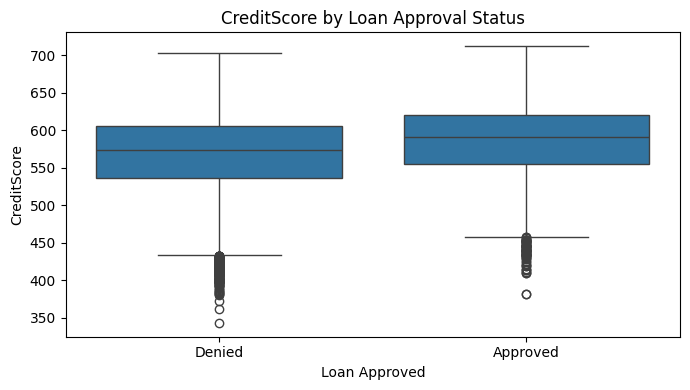

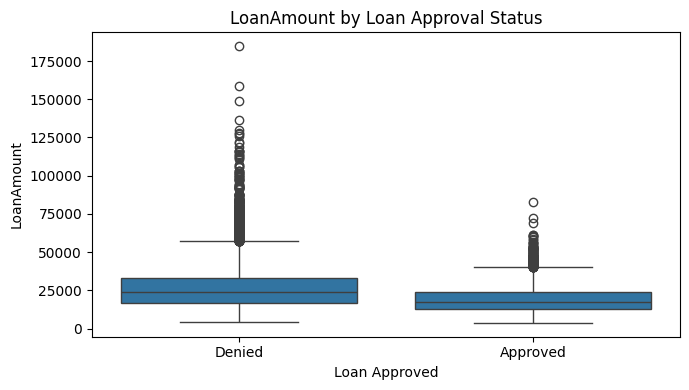

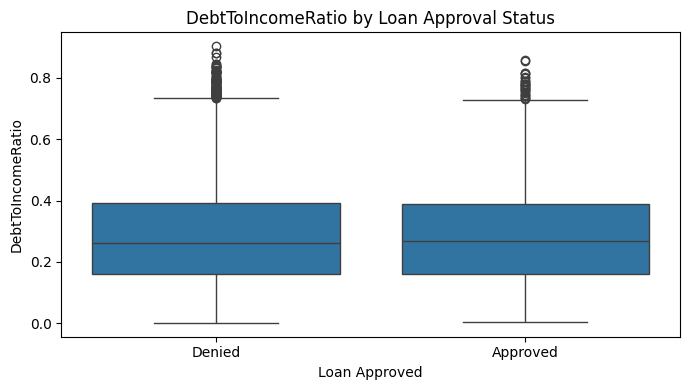

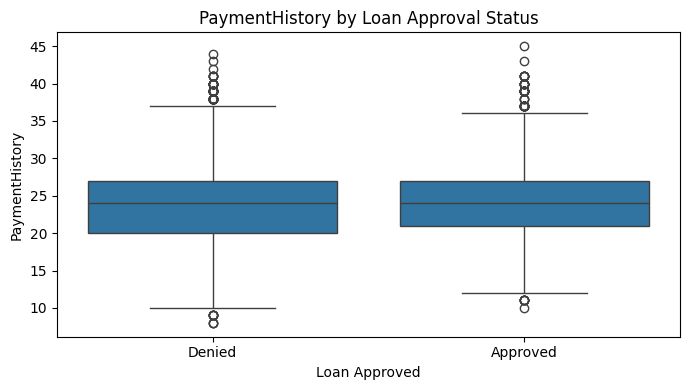

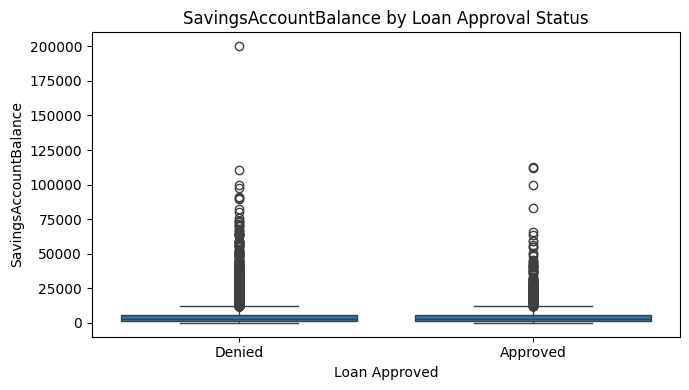

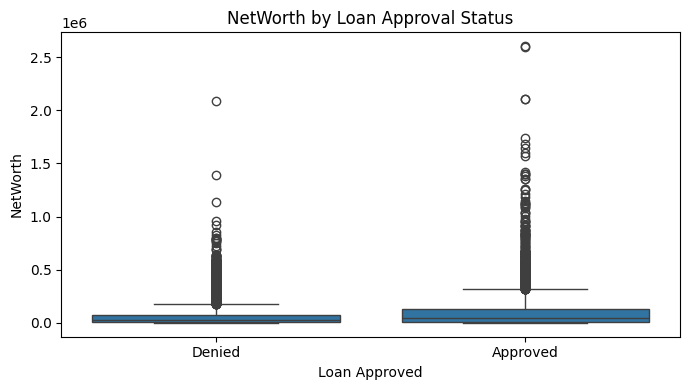

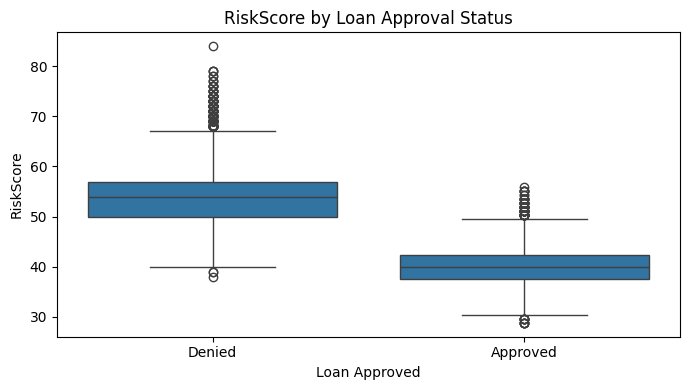

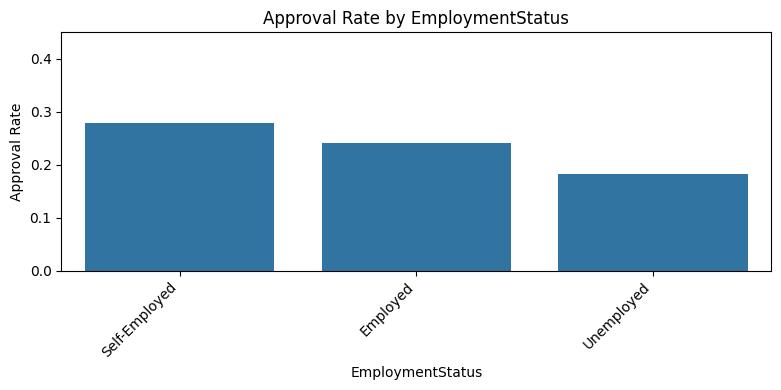

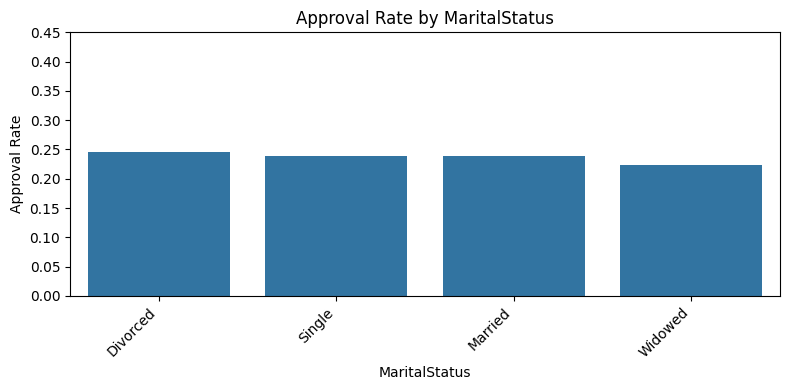

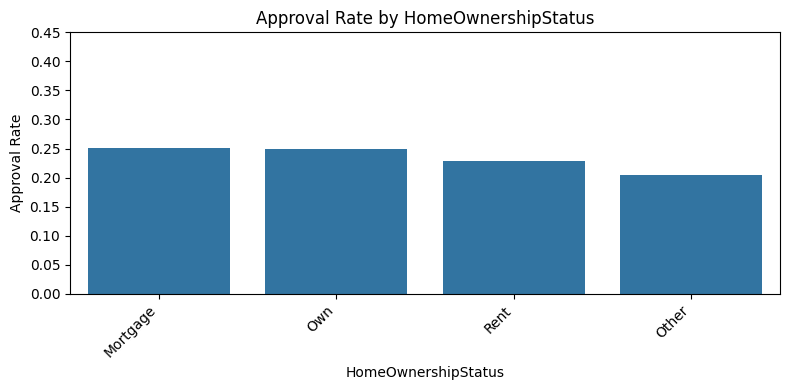

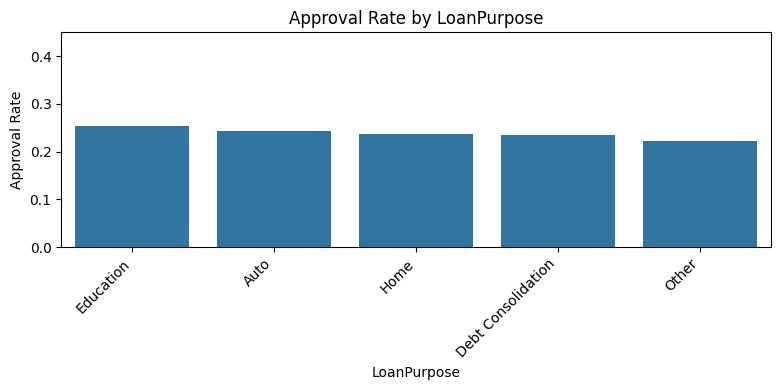

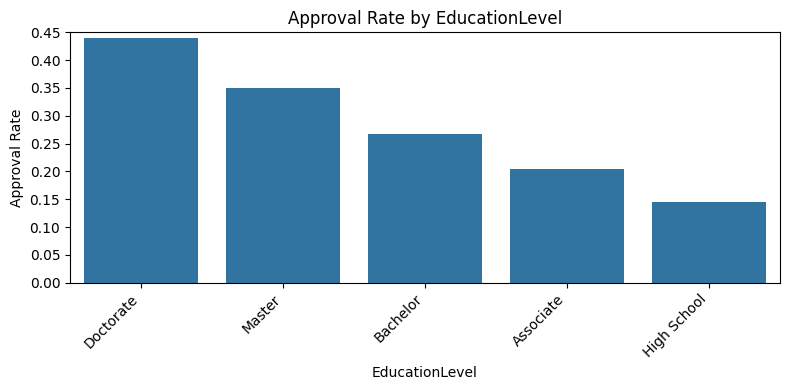

In [7]:
# Relationships with loan approval

# Important numerical features to compare with the target
comparison_features = [
    'Age',
    'AnnualIncome',
    'CreditScore',
    'LoanAmount',
    'DebtToIncomeRatio',
    'PaymentHistory',
    'SavingsAccountBalance',
    'NetWorth',
    'RiskScore'
]

for column in comparison_features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=loan_df,
        x='LoanApproved',
        y=column
    )

    plt.title(f'{column} by Loan Approval Status')
    plt.xlabel('Loan Approved')
    plt.xticks([0, 1], ['Denied', 'Approved'])
    plt.tight_layout()
    plt.show()

# Approval rate by categorical and ordinal features
for column in categorical_features + ordinal_features:
    approval_rate = (
        loan_df.groupby(column)['LoanApproved']
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    plt.figure(figsize=(8, 4))

    sns.barplot(
        data=approval_rate,
        x=column,
        y='LoanApproved'
    )

    plt.title(f'Approval Rate by {column}')
    plt.ylabel('Approval Rate')
    plt.ylim(0, 0.45)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

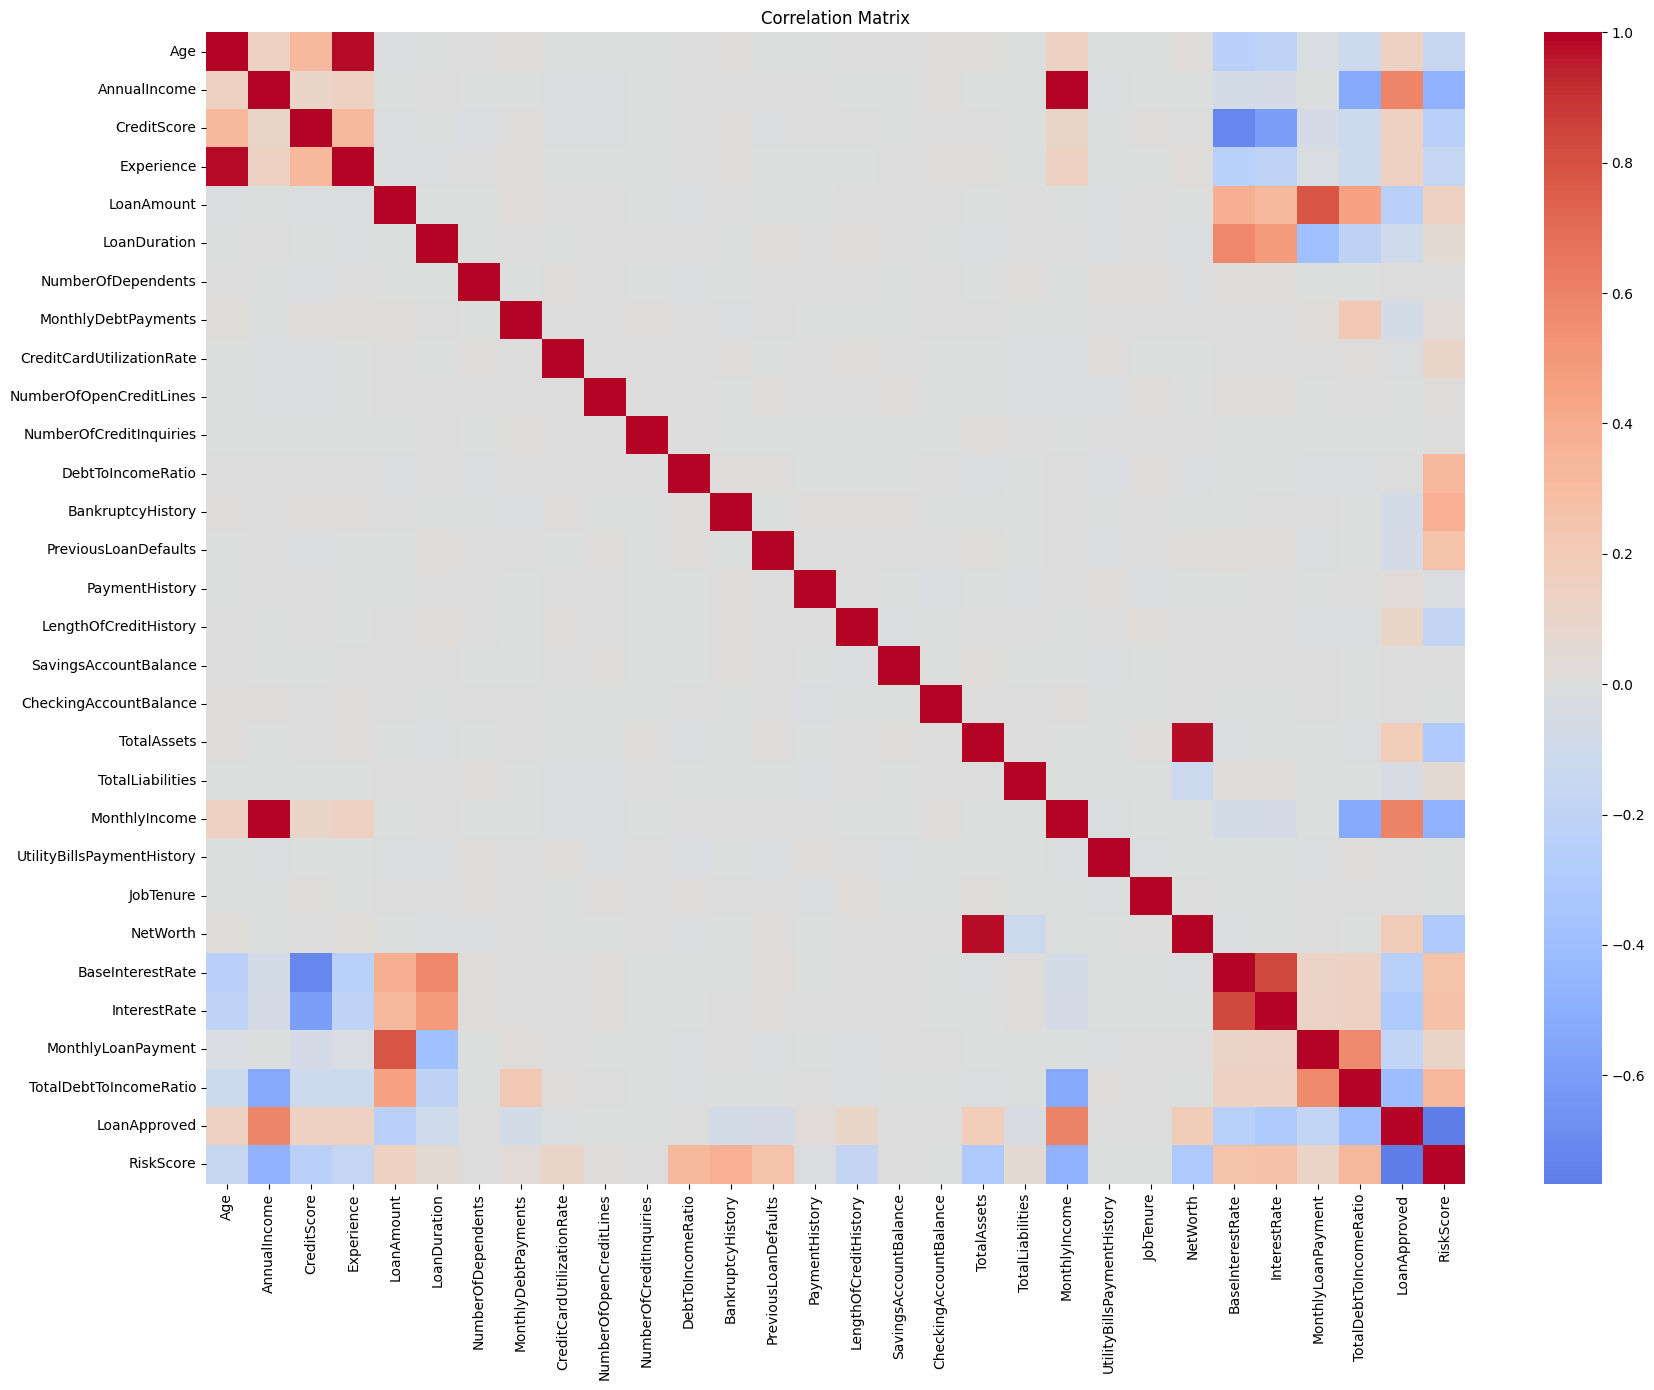

,CorrelationWithLoanApproved
RiskScore,-0.766137
MonthlyIncome,0.604101
AnnualIncome,0.597900
TotalDebtToIncomeRatio,-0.410399
InterestRate,-0.301646
BaseInterestRate,-0.247263
LoanAmount,-0.239496
NetWorth,0.187892
MonthlyLoanPayment,-0.184272
TotalAssets,0.184011


,Feature1,Feature2,Correlation
1,MonthlyIncome,AnnualIncome,0.989911
0,Experience,Age,0.982980
2,NetWorth,TotalAssets,0.978997
3,InterestRate,BaseInterestRate,0.834557
4,MonthlyLoanPayment,LoanAmount,0.780828
5,RiskScore,LoanApproved,-0.766137


In [8]:
# Correlation and multicollinearity

# Correlation matrix for numerical and binary features
numeric_df = loan_df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Display features most correlated with LoanApproved
approval_correlations = (
    correlation_matrix['LoanApproved']
    .drop('LoanApproved')
    .sort_values(key=abs, ascending=False)
)

display(
    approval_correlations.to_frame(
        'CorrelationWithLoanApproved'
    )
)

# Identify highly correlated feature pairs
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        correlation = correlation_matrix.iloc[i, j]

        if abs(correlation) >= 0.75:
            high_corr_pairs.append({
                'Feature1': correlation_matrix.columns[i],
                'Feature2': correlation_matrix.columns[j],
                'Correlation': correlation
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

if high_corr_df.empty:
    print('No feature pairs have correlation of 0.75 or higher.')
else:
    display(
        high_corr_df.sort_values(
            'Correlation',
            key=abs,
            ascending=False
        )
    )

In [9]:
# Data-quality checks and feature-engineering opportunities

# Check important ranges and invalid values
quality_checks = {
    'Age below 18': # loans should not be approved for individuals under 18
        (loan_df['Age'] < 18).sum(),

    'Age above 100': # loans very unlikely to be approved for individuals over 100
        (loan_df['Age'] > 100).sum(),

    'Negative annual income': # would not make sense to have a negative annual income
        (loan_df['AnnualIncome'] < 0).sum(),

    'Negative or zero loan amount': # would not make sense to have a loan amount of zero or less
        (loan_df['LoanAmount'] <= 0).sum(),

    'Credit score below 300': # minimum credit score value
        (loan_df['CreditScore'] < 300).sum(),

    'Credit score above 850': # max credit score value
        (loan_df['CreditScore'] > 850).sum(),

    'Credit utilization outside 0–1':
        (
            (loan_df['CreditCardUtilizationRate'] < 0) |
            (loan_df['CreditCardUtilizationRate'] > 1)
        ).sum(),

    'Unexpected LoanApproved values':
        (~loan_df['LoanApproved'].isin([0, 1])).sum(),

    'Unexpected BankruptcyHistory values':
        (~loan_df['BankruptcyHistory'].isin([0, 1])).sum(),

    'Unexpected PreviousLoanDefaults values':
        (~loan_df['PreviousLoanDefaults'].isin([0, 1])).sum()
}

display(
    pd.DataFrame(
        quality_checks.items(),
        columns=['QualityCheck', 'Count']
    )
)

,QualityCheck,Count
0,Age below 18,0
1,Age above 100,0
2,Negative annual income,0
3,Negative or zero loan amount,0
4,Credit score below 300,0
5,Credit score above 850,0
6,Credit utilization outside 0–1,0
7,Unexpected LoanApproved values,0
8,Unexpected BankruptcyHistory values,0
9,Unexpected PreviousLoanDefaults values,0


## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



### Data Preparation and Preprocessing Strategy

Different feature types require different preprocessing before model training.

- **Numerical features** will have missing values imputed using the median and then be standardized using `StandardScaler`. 
- **Categorical features** will have missing values replaced with the most frequent category and then be one-hot encoded so that machine learning models can interpret them correctly.
- **Ordinal features** (`EducationLevel`) will be ordinal encoded to preserve their natural ordering.
- **Binary features** are already encoded as 0/1 and will not require additional preprocessing.

The preprocessing steps will be combined using a `ColumnTransformer`, which allows different transformations to be applied to different feature types while keeping everything within a single machine learning pipeline.

### Remove "Leakange" features 
These features are likely to be highly correlated with the target variable, and were likely assigned as based on the company's evaluation of the applicant, as opposed to actually being features of the applicant themselves.  They would not be available as part of the actual modeling.  
- RiskScore
- InterestRate
- BaseInterestRate
- MonthlyLoanPayment


In [10]:
# Data Prep Code Here - Create New Cells As Needed

# Prepare data for modeling
# Separate predictors and target
X = loan_df.drop(columns=['LoanApproved'])
y = loan_df['LoanApproved']

# Remove ApplicationDate for now; not using it in modeling.  Also has a lot of values in the future, which would be a problem for modeling.
X = X.drop(columns=['ApplicationDate'])

# Remove possible target leakage features
# They were likely assigned as based on the company's evaluation of the applicant, as opposed to actually being features of the applicant themselves.  
leakage_features = [
    'RiskScore',
    'InterestRate',
    'BaseInterestRate',
    'MonthlyLoanPayment'
]

X = X.drop(columns=leakage_features)

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Feature matrix shape: (20000, 30)
Target shape: (20000,)


In [11]:
# Create preprocessing pipelines for different feature types

# Education order - ordinal encoded to preserve natural ordering
education_order = [
    ['High School',
     'Associate',
     'Bachelor',
     'Master',
     'Doctorate']
]

# numerical features to be used as predictors (excluding the leakage_features )
numerical_model_features = [
    col for col in numerical_features
    if col not in leakage_features
]

# binary features to be used as predictors (excluding the excluded features)
binary_predictor_features = [
    'BankruptcyHistory',
    'PreviousLoanDefaults'
]

# Numerical preprocessing - using median imputation as there are some extreme outliers in the numerical features, which would skew the mean. 
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing - imputation and onehotencoding, fill null values with most common
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Ordinal preprocessing - impute missing values with most common and encode using the specified order
ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', categories=education_order, unknown_value=-1))
])

# Combine transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_model_features),
        ('cat', categorical_transformer, categorical_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('bin', 'passthrough', binary_predictor_features)
    ],
    remainder='drop'
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 

### Implement  Modeling Approach
This project is a binary classification problem because the objective is to predict whether a loan application will be approved (`LoanApproved`). Two classification algorithms were selected for comparison: 
- **Logistic Regression** was selected because it is highly interpretable and provides a strong baseline model.  
- **Random Forest** was selected because it can capture more complex, non-linear relationships and interactions between features.

Before training the models, features that could introduce target leakage (`ApplicationDate`, `RiskScore`, `InterestRate`, `BaseInterestRate`, and `MonthlyLoanPayment`) were removed from the predictor set. The remaining data was split into 75% training and 25% testing sets using train_test_split() with random_state=42 to ensure reproducibility. The split was stratified on the target variable to preserve the proportion of approved and denied loans in both datasets.

Each model was built using a Pipeline, combining the preprocessing steps defined earlier with the classifier. Using a pipeline ensures that preprocessing is performed consistently during both training and evaluation while preventing data leakage during cross-validation.

Model performance was evaluated using 5-fold cross-validation. The primary evaluation metric was recall, because missing positive cases was considered the most important error based on the project requirements. F1-score was also tracked to provide a balanced measure of precision and recall.

### Optimize Model
Both models were optimized using GridSearchCV to identify the best combination of hyperparameters. Hyperparameter grids were intentionally kept relatively small to demonstrate the tuning process while keeping execution time reasonable.

For the **Random Forest** model, the tuning process evaluated:
- Numerical imputation strategy (mean or median)
- Number of trees (n_estimators)
- Maximum tree depth (max_depth)
- Minimum samples per leaf (min_samples_leaf)
- Class weighting (class_weight)

For **Logistic Regression**, the following parameters were tuned:
- Numerical imputation strategy (mean or median)
- Regularization strength (C)
- Class weighting (class_weight)
- Solver (liblinear or saga)

Each Grid Search used 5-fold cross-validation and evaluated both recall and F1-score, with recall selected as the metric used to determine the best model (refit='recall'). This approach ensured that all parameter combinations were evaluated consistently while balancing model performance with computational efficiency.

After tuning, the best cross-validation recall scores from both models were compared (best **Random Forest recall_score of 0.9024** and best **Logistic Regression recall_score of 0.9375**), and the model with the higher recall was selected (**Logistic Regression**) as the final model for evaluation on the held-out test set. Comparing both Logistic Regression and Random Forest also highlighted the trade-off between a simpler, more interpretable model and a more flexible model that may achieve higher predictive performance.

In [12]:
#  Modeling Code Here - Create New Cells as Needed

# Define columns that should not be used as predictors
excluded_features = [
    'LoanApproved',
    'ApplicationDate',
    'RiskScore',
    'InterestRate',
    'BaseInterestRate',
    'MonthlyLoanPayment'
]

# Split data into features and target
X = loan_df.drop(columns=excluded_features)
y = loan_df['LoanApproved']


# Split into training and test sets (75% train, 25% test) use random_state = 42 and set stratify = y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Create Random Forest pipeline (set random_state=42)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Create Logistic Regression pipeline (set random_state=42 and max_inter=1000)
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

print('Training feature shape:', X_train.shape)

print('Testing feature shape:', X_test.shape)

print('\nTraining target distribution:')
print(y_train.value_counts(normalize=True))

print('\nTesting target distribution:')
print(y_test.value_counts(normalize=True))

Training feature shape: (15000, 30)
Testing feature shape: (5000, 30)

Training target distribution:
LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64

Testing target distribution:
LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64


In [13]:
# Optimize model

# Define parameter grid for Random Forest
rf_param_grid = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__class_weight': ['balanced', None]
    }

# Define parameter grid for Logistic Regression
lr_param_grid = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'classifier__C': [0.1, 1.0, 10.0],
    'classifier__class_weight': ['balanced', None],
    'classifier__solver': ['liblinear', 'saga']
}

# Define scoring list
scoring = {
    'recall': 'recall',
    'f1': 'f1',
}

# Perform grid search for Random Forest (make sure to set scoring and refit appropriately)
rf_grid_search = None

rf_grid_search = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,  # 5-fold cross-validation
    scoring=scoring,
    refit='recall',  # Optimize for recall
    
    return_train_score=True,
    verbose=1
)

# Fit the Random Forest grid search
rf_grid_search.fit(X_train, y_train)

# Perform grid search for Logistic Regression (make sure to set scoring and refit appropriately)
lr_grid_search = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=5,
    scoring=scoring,
    refit='recall',  # Optimize for recall
    return_train_score=True,
    verbose=1
)

# Fit the Logistic Regression grid search
lr_grid_search.fit(X_train, y_train)

# Compare models
rf_best_cvscore = rf_grid_search.best_score_
lr_best_cvscore = lr_grid_search.best_score_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [14]:
# Run this cell without changes to display results
print(f'Best Random Forest recall_score: {rf_best_cvscore:.4f}')
print(f'Best Logistic Regression recall_score: {lr_best_cvscore:.4f}')

# Select the best model based on recall
if rf_best_cvscore >= lr_best_cvscore:
    best_model = rf_grid_search
    model_name = 'Random Forest'
else:
    best_model = lr_grid_search
    model_name = 'Logistic Regression'

print(f'\nBest model: {model_name}')

Best Random Forest recall_score: 0.9024
Best Logistic Regression recall_score: 0.9375

Best model: Logistic Regression


## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

### Evaluation and Conclusion

**Overview**:
- Using Logistics Regression Model (best performing model), we get:
   - Recall score of 0.926
   - F1-score of 0.830
   - ROC-AUC of 0.977
- Recall for when loan is Denied is 0.90 and f1 score is 0.94; recall for when loan is Approved is 0.93 and f1-score is 0.83.  , and 

**Model Limitations**
- Model was trained using historical loan approval decisions, so it may inherit biases present in previous manual lending decisions.
- Recall was prioritized because the project emphasized identifying positive cases, but increasing recall may reduce precision and increase false positives.
- Logistic Regression model performed the best.  While Logistic Regression offers greater interpretability, Random Forest can capture more complex relationships at the expense of explainability.
- Future work could evaluate fairness across applicant groups and monitor model performance after deployment.

In [15]:
# select grid search with highest cross-validation recall score
if rf_best_cvscore >= lr_best_cvscore:
    best_model = rf_grid_search
else:
    best_model = lr_grid_search

# Best estimator
final_model = best_model.best_estimator_

# Predictions
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_proba)

# Classification report
cr = classification_report(y_test, y_pred)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)


===== Final Model Evaluation =====
Recall : 0.9255
F1-score : 0.8300
ROC-AUC : 0.9768

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.90      0.94      3805
           1       0.75      0.93      0.83      1195

    accuracy                           0.91      5000
   macro avg       0.86      0.91      0.88      5000
weighted avg       0.92      0.91      0.91      5000



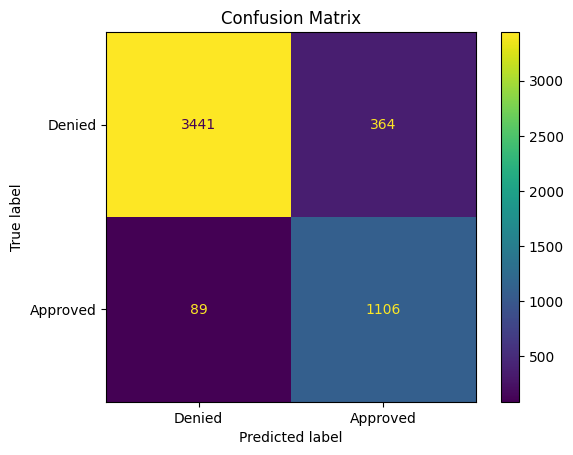

In [16]:
# Final evaluation of the model on the test set
print('\n===== Final Model Evaluation =====')

print(f'Recall : {test_recall:.4f}')
print(f'F1-score : {test_f1:.4f}')
print(f'ROC-AUC : {test_auc:.4f}')

print('\nClassification Report')
print(cr)

ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Approved']).plot()

plt.title('Confusion Matrix')
plt.show()

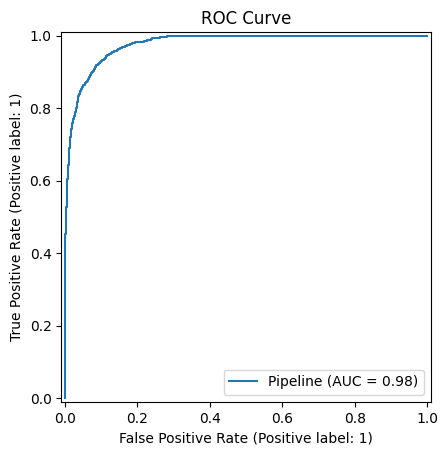

In [17]:
# visualize ROC curve

RocCurveDisplay.from_estimator(final_model, X_test, y_test)

plt.title('ROC Curve')
plt.show()

In [18]:
# Extract feature names after preprocessing
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

# Remove transformer prefixes (num__, cat__, ord__, bin__)
feature_names = [name.split('__', 1)[1] if '__' in name else name
    for name in feature_names
]

# Extract Logistic Regression coefficients
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': final_model.named_steps[
        'classifier'
    ].coef_[0]
})

# Sort by absolute coefficient magnitude
coefficients['AbsCoefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='AbsCoefficient',ascending=False)

display(coefficients.head(10))

,Feature,Coefficient,AbsCoefficient
22,TotalDebtToIncomeRatio,-3.547845,3.547845
36,BankruptcyHistory,-2.722515,2.722515
18,MonthlyIncome,1.951894,1.951894
37,PreviousLoanDefaults,-1.893471,1.893471
4,LoanAmount,-1.708917,1.708917
24,EmploymentStatus_Unemployed,-1.202567,1.202567
5,LoanDuration,-1.151947,1.151947
21,NetWorth,0.896176,0.896176
13,LengthOfCreditHistory,0.817734,0.817734
1,AnnualIncome,0.612297,0.612297


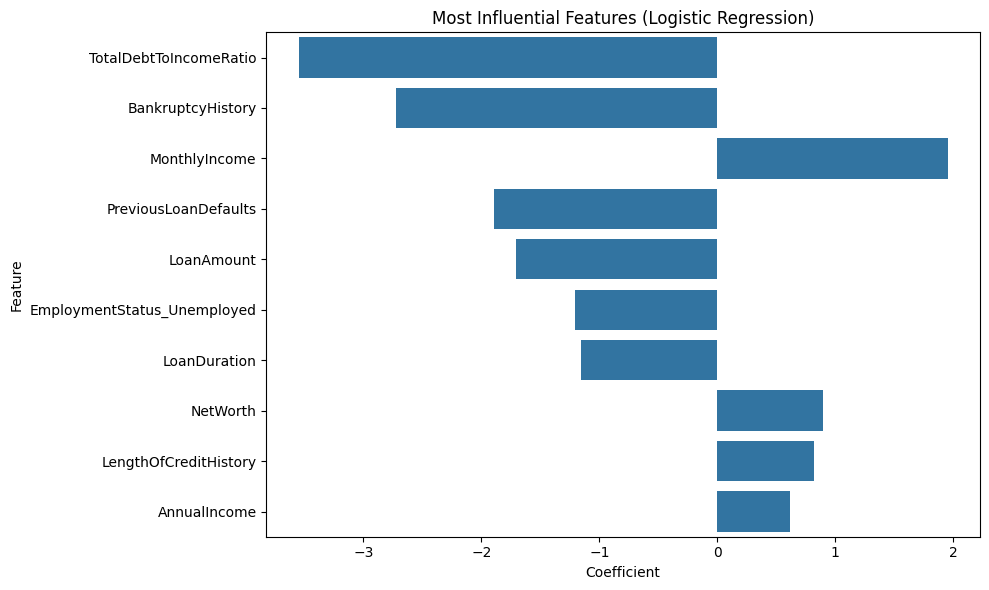

In [19]:
top_features = coefficients.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Coefficient',
    y='Feature'
)

plt.title('Most Influential Features (Logistic Regression)')
plt.tight_layout()
plt.show()

### Extract and interpret feature importance/significance

**Feature Importance:**
Because the final model was Logistic Regression, feature importance was evaluated using model coefficients. Features with larger absolute coefficient values had the greatest influence on the model's loan approval predictions.
The ten most influential features were:

| Feature                                 | Interpretation                                                                               |
| --------------------------------------- | -------------------------------------------------------------------------------------------- |
| **TotalDebtToIncomeRatio** (-3.55)      | Applicants with higher overall debt relative to income were much less likely to be approved. |
| **BankruptcyHistory** (-2.72)           | A history of bankruptcy strongly decreased the likelihood of loan approval.                  |
| **MonthlyIncome** (+1.95)               | Higher monthly income increased the likelihood of approval.                                  |
| **PreviousLoanDefaults** (-1.89)        | Applicants with previous loan defaults were less likely to be approved.                      |
| **LoanAmount** (-1.71)                  | Larger requested loans reduced the probability of approval.                                  |
| **EmploymentStatus_Unemployed** (-1.20) | Unemployed applicants were less likely to receive loan approval.                             |
| **LoanDuration** (-1.15)                | Longer loan terms were associated with a lower probability of approval.                      |


**Business Recommendations**
- Place emphasis on debt-to-income ratio, bankruptcy history, and previous loan defaults when deciding on approving/denying a loan, as these were the strongest indicators associated with loan approval decisions.
- Evaluate applicants using multiple financial measures, including monthly income, annual income, and net worth, rather than relying on a single income measure.
- Use the model as a support tool for loan officers rather than fully automating decisions. The model can quickly identify low-risk and high-risk applicants while allowing loan officers to review borderline cases.
- Regularly retrain the model using updated lending data and monitor its performance over time to ensure that important predictors remain relevant as conditions and customer behavior change.
- Evaluate the model for potential fairness concerns before deployment. Some influential variables, such as employment or marital status, may indirectly correlate with protected groups.